In [ ]:
## Convert ase trajectory
# ! rm ../output/wat_mace_small/wat_300_npt.pdb
# ase convert ../output/wat_mace_small/wat_300_npt.traj ../output/wat_mace_small/wat_300_npt.pdb
# ! rm ../output/wat_grace_medium_a_wpS/wat_300_npt.pdb
# ase convert ../output/wat_grace_medium_a_wpS/wat_300_npt.traj ../output/wat_grace_medium_a_wpS/wat_300_npt.pdb

In [10]:
from MDAnalysis.analysis.rdf import InterRDF
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
mace_small= mda.Universe("../output/wat_mace_small/wat_300_npt.pdb")
grace_medium= mda.Universe("../output/wat_grace_medium_a_wpS/wat_300_npt.pdb")



model_rdf=dict()

for u in [mace_small, grace_medium]:
    irdf2=dict()

    oxygen = u.select_atoms('name O*')
    hydrogen = u.select_atoms('name H*')

    
    for i, combination in enumerate(["o-o","o-h","h-h"]):
        if combination == "o-o":
            group1 = oxygen
            group2 = oxygen
            exclusion_block=(1, 1)
        elif combination == "o-h":
            group1 = oxygen
            group2 = hydrogen
            exclusion_block=(1, 2)
        elif combination == "h-h":
            group1 = hydrogen
            group2 = hydrogen
            exclusion_block=(2, 2)


        irdf2[combination] = InterRDF(group1, group2,
                            nbins=75,  # default
                            range=(0.0, 12.0),  # distance in angstroms
                            exclusion_block=exclusion_block,  # exclude intramolecular pairs
                        )
        irdf2[combination].run(step=100)

        

    
    model_rdf[u]=irdf2
    
plt.tight_layout()
plt.show()


/scratch/data/anna/miniconda3/envs/statistics_new/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:522: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


<Figure size 640x480 with 0 Axes>

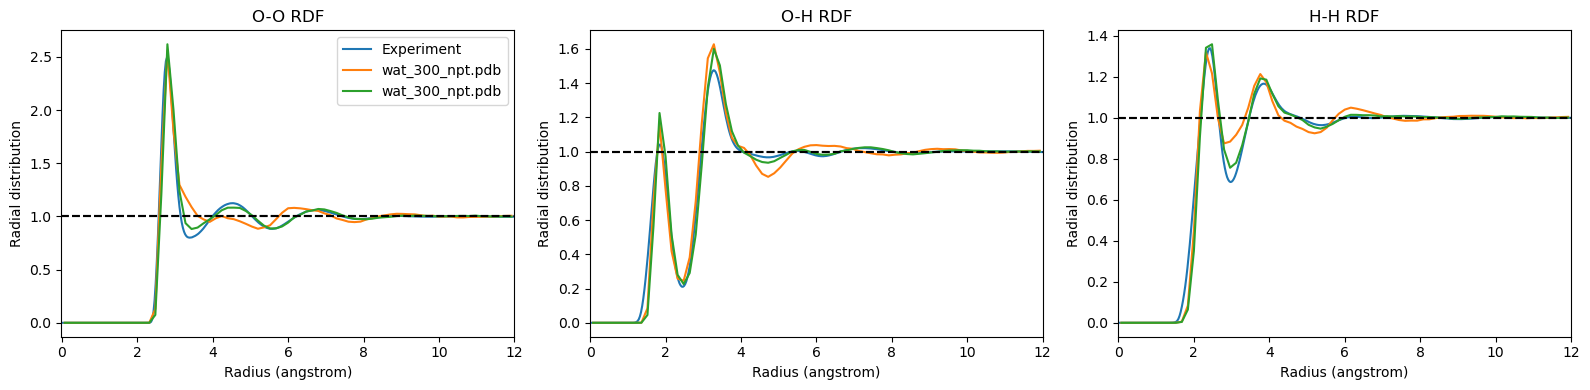

In [14]:
# water data ----------------------------------

exp_water = pd.read_csv("/site/raid3/anna/test_waterbox/exp_water.dat", delimiter='\t')
r_A=exp_water[" r[A] "]
rdf_exp_OO=exp_water["O–O "]
rdf_exp_Oh=exp_water["O–H "]
rdf_exp_hh=exp_water["H–H "]
xlim_lower, xlim_upper = -0.2, 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(r_A, rdf_exp_OO, label = "Experiment")
axes[1].plot(r_A, rdf_exp_Oh, label = "Experiment")
axes[2].plot(r_A, rdf_exp_hh, label = "Experiment")


for u in [mace_small, grace_medium]:
        rdf=model_rdf[u]
        for i, combination in enumerate(["o-o","o-h","h-h"]):

                axes[i].plot(rdf[combination].results.bins, rdf[combination].results.rdf, label = u.filename.split('/')[-1] )
                axes[i].axhline(y=1, color='k', linestyle='--')
                axes[i].set_xlabel('Radius (angstrom)')
                axes[i].set_ylabel('Radial distribution')
                axes[i].set_title(f'{combination.upper()} RDF')
                axes[i].set_xlim(-0.01, 12)
                axes[0].legend()
    
plt.tight_layout()
# plt.savefig("waterbox_rdf_comparison_exp.png", dpi=300)
plt.show()
